In [ ]:
!git clone https://github.com/zhixuhao/unet.git


fatal: destination path 'unet' already exists and is not an empty directory.


In [ ]:
import os

os.listdir("unet/data/membrane/train")


['label', 'aug', 'image']

In [ ]:
!pip install opencv-python tensorflow scikit-learn matplotlib


In [ ]:
import cv2
import numpy as np
import os

image_path = "unet/data/membrane/train/image"
mask_path = "unet/data/membrane/train/label"

IMG_SIZE = 128

images = []
masks = []

files = os.listdir(image_path)

for file in files:

    img = cv2.imread(os.path.join(image_path, file))
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))

    mask = cv2.imread(os.path.join(mask_path,file),0)
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    images.append(img)
    masks.append(mask)

images = np.array(images)/255
masks = np.array(masks)/255

print("Images shape:",images.shape)
print("Masks shape:",masks.shape)


Images shape: (30, 128, 128, 3)
Masks shape: (30, 128, 128)


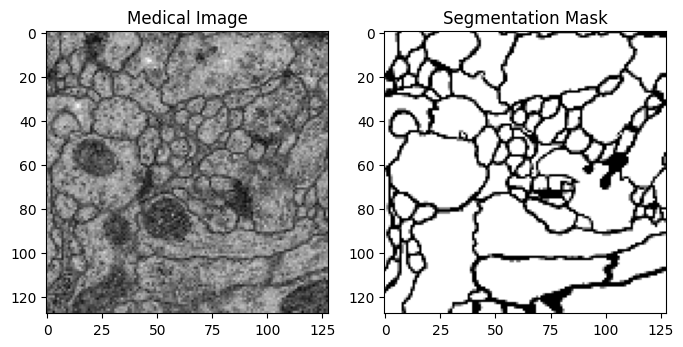

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(images[0])
plt.title("Medical Image")

plt.subplot(1,2,2)
plt.imshow(masks[0],cmap="gray")
plt.title("Segmentation Mask")

plt.show()


In [ ]:
masks = np.expand_dims(masks, axis=-1)

print(masks.shape)


(30, 128, 128, 1)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate

def build_unet(input_shape=(128,128,3)):

    inputs = Input(input_shape)

    c1 = Conv2D(16,3,activation='relu',padding='same')(inputs)
    c1 = Conv2D(16,3,activation='relu',padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(32,3,activation='relu',padding='same')(p1)
    c2 = Conv2D(32,3,activation='relu',padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(64,3,activation='relu',padding='same')(p2)
    c3 = Conv2D(64,3,activation='relu',padding='same')(c3)

    u4 = Conv2DTranspose(32,2,strides=2,padding='same')(c3)
    u4 = concatenate([u4,c2])
    c4 = Conv2D(32,3,activation='relu',padding='same')(u4)
    c4 = Conv2D(32,3,activation='relu',padding='same')(c4)

    u5 = Conv2DTranspose(16,2,strides=2,padding='same')(c4)
    u5 = concatenate([u5,c1])
    c5 = Conv2D(16,3,activation='relu',padding='same')(u5)
    c5 = Conv2D(16,3,activation='relu',padding='same')(c5)

    outputs = Conv2D(1,1,activation='sigmoid')(c5)

    model = Model(inputs,outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_unet()

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 128, 128,  │      2,320 │ conv2d_11[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_13[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │     36,928 │ conv2d_15[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 64, 64,    │      8,224 │ conv2d_16[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     18,464 │ concatenate_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │      9,248 │ conv2d_17[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 128, 128,  │      2,064 │ conv2d_18[0][0]   │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │      4,624 │ concatenate_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │      2,320 │ conv2d_19[0][0] 

 Total params: 117,041 (457.19 KB)

 Trainable params: 117,041 (457.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    images,
    masks,
    epochs=20,
    batch_size=4,
    validation_split=0.1
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 781ms/step - accuracy: 0.7125 - loss: 0.6351 - val_accuracy: 0.7277 - val_loss: 0.5374
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7420 - loss: 0.5213 - val_accuracy: 0.7277 - val_loss: 0.5184
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7420 - loss: 0.4990 - val_accuracy: 0.7277 - val_loss: 0.5092
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7420 - loss: 0.4861 - val_accuracy: 0.7277 - val_loss: 0.4915
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7421 - loss: 0.4693 - val_accuracy: 0.7281 - val_loss: 0.4713
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7437 - loss: 0.4488 - val_accuracy: 0.7302 - val_loss: 0.4465
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7482 - loss: 0.4227 - val_accuracy: 0.7571 - val_loss: 0.4263
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7621 - loss: 0.4042 - val_accuracy: 0.7592 - val_loss: 0.396

In [ ]:
pred_masks = model.predict(images)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


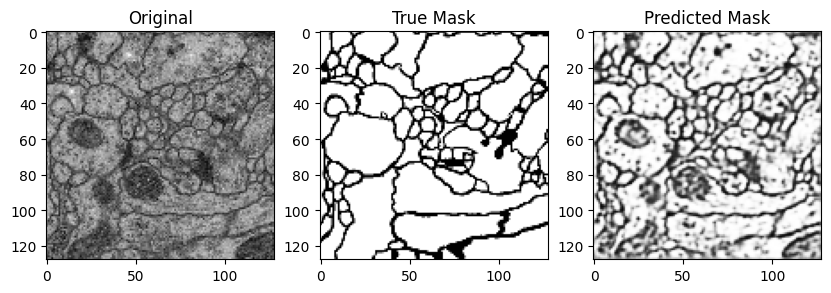

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(images[0])
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(masks[0].squeeze(),cmap="gray")
plt.title("True Mask")

plt.subplot(1,3,3)
plt.imshow(pred_masks[0].squeeze(),cmap="gray")
plt.title("Predicted Mask")

plt.show()


In [ ]:
X = images.reshape(images.shape[0], -1)

print("Flattened dataset shape:", X.shape)


Flattened dataset shape: (30, 49152)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.10054174 0.06956799]


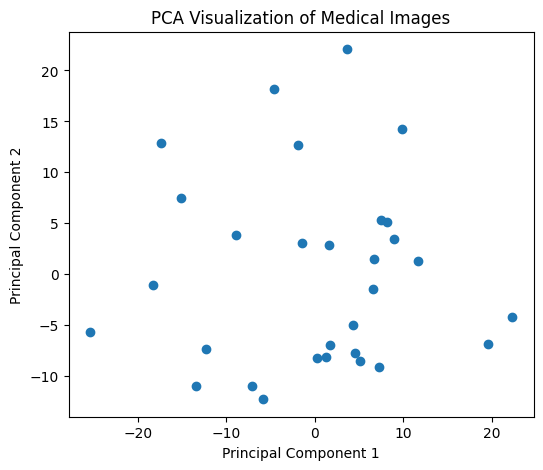

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0], X_pca[:,1])

plt.title("PCA Visualization of Medical Images")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()


In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=5,
    random_state=42
)

X_tsne = tsne.fit_transform(X)


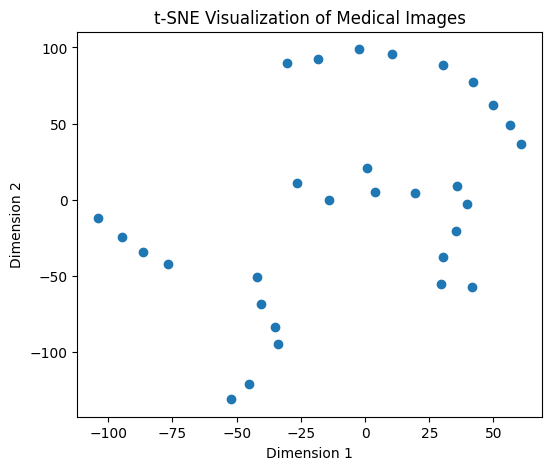

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(X_tsne[:,0], X_tsne[:,1])

plt.title("t-SNE Visualization of Medical Images")

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()


In [ ]:
import numpy as np

def iou_score(y_true, y_pred, threshold=0.5):

    y_pred = y_pred > threshold

    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()

    if union == 0:
        return 0
    return intersection / union


ious = []

for i in range(len(images)):

    score = iou_score(
        masks[i].squeeze(),
        pred_masks[i].squeeze()
    )

    ious.append(score)

print("Mean IoU:", np.mean(ious))


Mean IoU: 0.8388566140389206


In [ ]:
import matplotlib.pyplot as plt

def overlay_mask(image, mask, alpha=0.5):

    overlay = image.copy()

    overlay[:,:,0] = np.where(
        mask>0.5,
        1,
        overlay[:,:,0]
    )

    return overlay


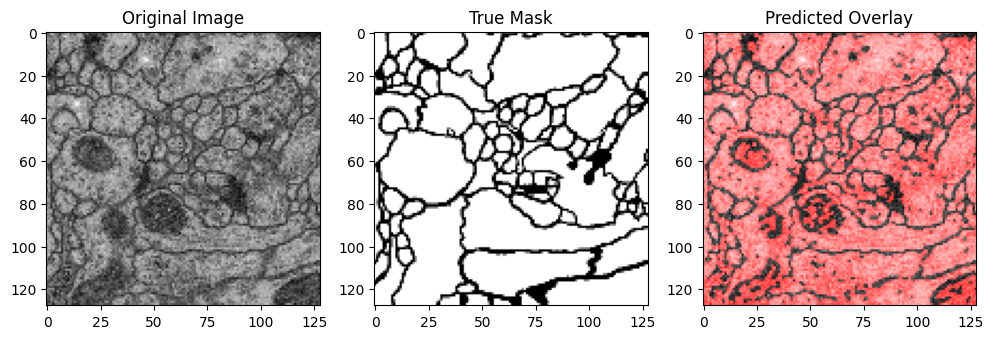

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[0])
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(masks[0].squeeze(), cmap="gray")
plt.title("True Mask")

plt.subplot(1,3,3)
plt.imshow(overlay_mask(images[0], pred_masks[0].squeeze()))
plt.title("Predicted Overlay")

plt.show()


In [ ]:
import os

os.makedirs("results", exist_ok=True)


In [ ]:
for i in range(5):

    fig = plt.figure(figsize=(8,4))

    plt.subplot(1,3,1)
    plt.imshow(images[i])
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(masks[i].squeeze(), cmap="gray")
    plt.title("True Mask")

    plt.subplot(1,3,3)
    plt.imshow(overlay_mask(images[i], pred_masks[i].squeeze()))
    plt.title("Prediction")

    plt.savefig(f"results/example_{i}.png")

    plt.close()

print("Saved segmentation examples.")


Saved segmentation examples.


In [ ]:
import os
os.listdir("results")


['example_3.png',
 'example_2.png',
 'example_0.png',
 'example_1.png',
 'example_4.png']

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

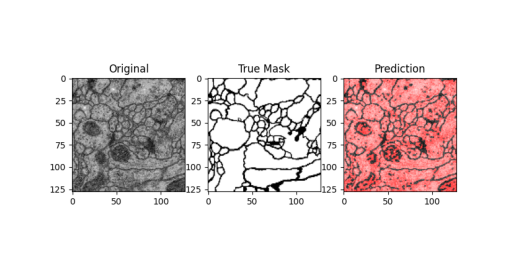

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("results/example_0.png")

plt.imshow(img)
plt.axis("off")


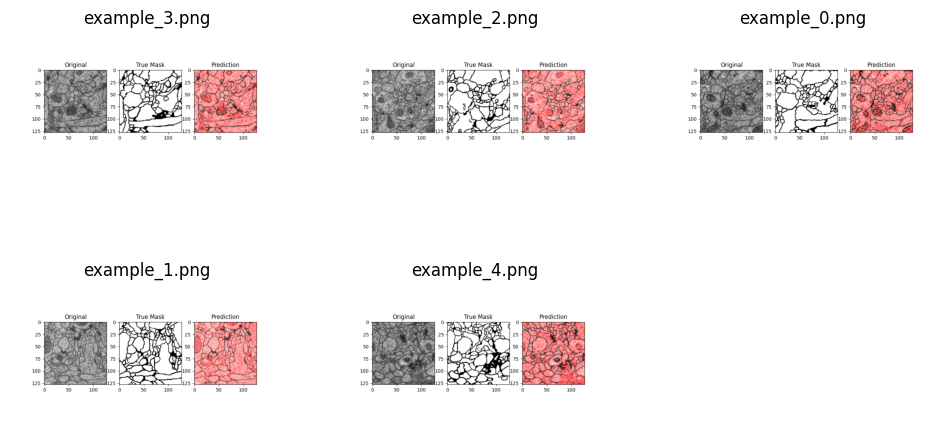

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

files = os.listdir("results")

plt.figure(figsize=(12,6))

for i,file in enumerate(files):

    img = Image.open("results/"+file)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

plt.show()
